In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFT, UnitaryGate
from qiskit_aer import AerSimulator
from qiskit.circuit.library import PhaseEstimation
import numpy as np

In [2]:
def get_diffusion_matrix(adj_list, node_idx, num_qubits):
    """Creates the reflection matrix D_x = 2|phi_x><phi_x| - I"""
    N = 2**num_qubits
    phi_x = np.zeros(N)
    neighbors = adj_list[node_idx]
    
    total_weight = sum(w for _, w in neighbors)
    for y, w in neighbors:
        phi_x[y] = np.sqrt(w / total_weight)
        
    projection = np.outer(phi_x, phi_x)
    return 2 * projection - np.eye(N)


def get_initial_state_vector(adj_list, s, node_qubits):
    """
    Creates the exact state vector for the antisymmetrized star state |phi_s^->.
    Corrected for Qiskit's Little-Endian tensor product ordering.
    """
    N = 2**node_qubits
    vec = np.zeros(N * N, dtype=complex) 
    
    neighbors = adj_list[s]
    total_weight = sum(w for _, w in neighbors)
    
    for y, w in neighbors:
        amp = np.sqrt(w / total_weight) / np.sqrt(2)
        # Corrected Indexing: v * N + u
        vec[y * N + s] += amp  # Represents state |u=s, v=y>
        vec[s * N + y] -= amp  # Represents state |u=y, v=s>
        
    return vec

def build_U_gate(adj_list, s, t, node_qubits):
    """Constructs the Walk Operator U = SWAP * (Direct Sum of D_x)"""

    #The register |u,v> repersents the state of the walk, where |u> is the current node and |v> is the next node.
    n_nodes = len(adj_list)
    reg_u = QuantumRegister(node_qubits, 'u')
    reg_v = QuantumRegister(node_qubits, 'v')
    qc_u = QuantumCircuit(reg_u, reg_v, name='U_walk')

    # Apply Conditional Reflections D_x
    for x in range(n_nodes):
        if x == s or x == t:
            # -I boundary conditions for source/sink
            D_x_mat = -np.eye(2**node_qubits)
        else:
            # Internal node reflections
            D_x_mat = get_diffusion_matrix(adj_list, x, node_qubits)
            
        D_x_gate = UnitaryGate(D_x_mat, label=f'D_{x}')
        ctrl_state_str = format(x, f'0{node_qubits}b')
        c_D_x = D_x_gate.control(num_ctrl_qubits=node_qubits, ctrl_state=ctrl_state_str) #a multi control gate that applies D_x only when reg_u is in state |x>
        qc_u.append(c_D_x, [*reg_u, *reg_v])

    # Apply SWAP basically swaps the registers |u> and |v>, which corresponds to moving from the current node to the next node in the walk.
    for i in range(node_qubits):
        qc_u.swap(reg_u[i], reg_v[i])

    return qc_u.to_gate()


def build_flow_circuit(adj_list, s, t, precision):
    """Assembles the QPE circuit using Qiskit's built-in PhaseEstimation."""
    n_nodes = len(adj_list)
    node_qubits = int(np.ceil(np.log2(n_nodes))) #how many qubits are required

    # Registers
    ctrl = QuantumRegister(precision, 'phase')
    reg_u = QuantumRegister(node_qubits, 'u')
    reg_v = QuantumRegister(node_qubits, 'v')
    
    c_phase = ClassicalRegister(precision, 'c_phase')
    c_u = ClassicalRegister(node_qubits, 'c_u')
    c_v = ClassicalRegister(node_qubits, 'c_v')
    
    qc = QuantumCircuit(ctrl, reg_u, reg_v, c_phase, c_u, c_v)

    # Initialize Edge Registers to the antisymmetrized star state
    init_vec = get_initial_state_vector(adj_list, s, node_qubits)
    qc.initialize(init_vec, [*reg_u, *reg_v])

    # Construct the Walk Operator U
    U_gate = build_U_gate(adj_list, s, t, node_qubits)
    
    # 3. Apply the built-in Phase Estimation
    # This automatically builds the Hadamards, the CU^(2^i) sequence, and the IQFT
    qpe_block = PhaseEstimation(precision, U_gate)
    
    # Append it to the circuit. 
    # QPE expects the evaluation (clock) qubits first, then the state qubits.
    qc.append(qpe_block, [*ctrl, *reg_u, *reg_v])

    # 4. Measure all registers
    qc.measure(ctrl, c_phase)
    qc.measure(reg_u, c_u)
    qc.measure(reg_v, c_v)

    return qc, node_qubits


def extract_quantum_flow(graph, source, sink, precision_qubits, shots=2048):
    """
    Executes the quantum flow state simulation and extracts edge probabilities.
    Returns a dictionary mapping edges to their measured flow probabilities.
    """
    print(f"Building circuit for {source} -> {sink}...")
    qc, node_q = build_flow_circuit(graph, source, sink, precision_qubits)
    
    backend = AerSimulator()
    compiled_circuit = transpile(qc, backend)
    job = backend.run(compiled_circuit, shots=shots)
    counts = job.result().get_counts()

    flow_edges = {}
    target_phase = '0' * precision_qubits
    total_successes = 0

    # Parse Qiskit's bitstring format: "c_v c_u c_phase"
    for bitstring, count in counts.items():
        v_str, u_str, phase_str = bitstring.split(' ')
        
        # Post-select for Phase = 0
        if phase_str == target_phase:
            total_successes += count
            u_node = int(u_str, 2)
            v_node = int(v_str, 2)
            
            # Sort to aggregate undirected edges
            edge = tuple(sorted((u_node, v_node)))
            flow_edges[edge] = flow_edges.get(edge, 0) + count

    # Calculate final probability distribution
    edge_probabilities = {}
    if total_successes > 0:
        print(f"\n--- RESULTS ({source}->{sink}) ---")
        print(f"Total Successful Projections (Phase = {target_phase}): {total_successes}")
        print("Probability Distribution of Edges in Flow State:")
        
        for edge, count in flow_edges.items():
            prob = count / total_successes
            edge_probabilities[edge] = prob
            print(f"  Edge {edge}: {prob:.4f}")
    else:
        print("\n--- RESULTS ---")
        print("No successful phase measurements. Try increasing precision or shots.")
        
    return edge_probabilities


def get_effective_resistance(adj_list, s, t):
    """Calculates R_eff(s, t) using the Laplacian matrix."""
    n = len(adj_list)
    L = np.zeros((n, n))
    
    # Build the Laplacian Matrix: L = Degree - Adjacency
    # We assume the weights 'w' represent conductance (1/Resistance)
    for u in adj_list:
        for v, w in adj_list[u]:
            L[u, u] += w        # Add to degree (diagonal)
            L[u, v] -= w        # Subtract from adjacency (off-diagonal)
            
    # Use the Moore-Penrose pseudoinverse to solve the system
    L_pinv = np.linalg.pinv(L)
    
    # R_eff(s,t) = L^+_ss + L^+_tt - 2 * L^+_st
    r_eff = L_pinv[s, s] + L_pinv[t, t] - 2 * L_pinv[s, t]
    
    # If the graph is disconnected, pinv might yield near-zero or garbage. 
    # A true disconnect approaches infinite resistance.
    if np.isclose(r_eff, 0.0) and s != t:
        return float('inf')
        
    return abs(r_eff)


def remove_edge(adj_list, u, v):
    """Returns a new graph with the edge (u, v) removed."""
    new_adj = {node: list(edges) for node, edges in adj_list.items()}
    new_adj[u] = [(n, w) for n, w in new_adj[u] if n != v]
    new_adj[v] = [(n, w) for n, w in new_adj[v] if n != u]
    return new_adj

def run_quantum_subroutine(adj_list, s, t, precision=3, shots=2048):
    """
    Wraps the Qiskit code we built earlier.
    Returns a sorted list of candidate edges based on flow probabilities.
    """
    print(f"  [Quantum] Sifting flow state for {s} -> {t}...")
    qc, node_q = build_flow_circuit(adj_list, s, t, precision)
    
    backend = AerSimulator()
    compiled = transpile(qc, backend)
    counts = backend.run(compiled, shots=shots).result().get_counts()
    
    target_phase = '0' * precision
    flow_edges = {}
    
    for bitstring, count in counts.items():
        v_str, u_str, phase_str = bitstring.split(' ')
        if phase_str == target_phase:
            u_node, v_node = int(u_str, 2), int(v_str, 2)
            edge = tuple(sorted((u_node, v_node)))
            flow_edges[edge] = flow_edges.get(edge, 0) + count
            
    # Return edges sorted by probability (highest first)
    return sorted(flow_edges.keys(), key=lambda e: flow_edges[e], reverse=True)


def algorithm_2(adj_list, s, t, precision=3):
    """
    The main recursive Divide and Conquer algorithm.
    """
    # Base Case 1: Reached the target
    if s == t:
        return []
        
    # Base Case 2: Only one direct edge connects them (No other paths)
    r_current = get_effective_resistance(adj_list, s, t)
    test_graph = remove_edge(adj_list, s, t)
    if get_effective_resistance(test_graph, s, t) == float('inf'):
        return [(s, t)]

    # 1. Quantum Sampling: Get candidate edges
    candidates = run_quantum_subroutine(adj_list, s, t, precision)
    
    if not candidates:
        print(f"  [Warning] Quantum walk failed to find edges for {s}->{t}. Falling back.")
        return [(s, t)] # Fallback if precision/shots fail

    # 2. Classical Validation: Find the resistance spike
    max_resistance = -1
    e_star = None
    
    for u, v in candidates[:3]: # Only check the top few candidates to save time
        temp_graph = remove_edge(adj_list, u, v)
        r_temp = get_effective_resistance(temp_graph, s, t)
        
        if r_temp > max_resistance:
            max_resistance = r_temp
            e_star = (u, v)

    print(f"  [Classical] Validated e* = {e_star} (Spike: {r_current:.3f} -> {max_resistance:.3f})")
    
    # 3. Orient the edge: Ensure u is closer to s than v
    u, v = e_star
    if get_effective_resistance(adj_list, s, u) > get_effective_resistance(adj_list, s, v):
        u, v = v, u # Swap them

    # 4. Divide and Conquer: Split the problem
    print(f"  [Split] Dividing at {u}-{v}. Sub-problems: ({s}->{u}) and ({v}->{t})")
    left_path = algorithm_2(adj_list, s, u, precision)
    right_path = algorithm_2(adj_list, v, t, precision)

    # Recombine the path
    return left_path + [(u, v)] + right_path

In [3]:
def generate_full_path_routing_table(adj_list, sequence_nodes):
    """
    Generates a full-path routing table for the custom network simulator.
    
    Output Format:
    routing_table[src][dst] = [("node1", "node2", dist1), ("node2", "node3", dist2)]
    This matches the exact 'path_details' format expected by the swap() function.
    """
    # Create mappings: 'r1' -> 0, 'r2' -> 1, etc.
    str_to_int = {name: idx for idx, name in enumerate(sequence_nodes)}
    int_to_str = {idx: name for idx, name in enumerate(sequence_nodes)}
    
    # Initialize a nested dictionary to store paths: {src: {dst: []}}
    routing_table = {node: {} for node in sequence_nodes}
    
    for src in sequence_nodes:
        for dst in sequence_nodes:
            if src == dst:
                continue
            
            # --- OPTIMIZATION ---
            # Check if we've already computed the reverse path (dst -> src)
            if dst in routing_table and src in routing_table[dst]:
                # print(f"--- Using cached reverse route for {src} -> {dst} ---")
                reverse_path = routing_table[dst][src]
                # Reverse the order of edges and flip the source/destination of each edge
                routing_table[src][dst] = [(v, u, dist) for u, v, dist in reversed(reverse_path)]
                continue
                
            src_idx = str_to_int[src]
            dst_idx = str_to_int[dst]
            
            # 1. Check if the nodes are directly connected and extract distance
            neighbors = adj_list.get(src_idx, [])
            is_directly_connected = False
            distance = 0.0
            
            for neighbor in neighbors:
                # Handle weighted tuples [(node, weight)]
                if isinstance(neighbor, (tuple, list)) and neighbor[0] == dst_idx:
                    is_directly_connected = True
                    distance = neighbor[1]
                    break

            if is_directly_connected:
                print(f"--- Direct route used for {src} -> {dst} ---")
                
                # Format exactly like path_details: list of (src, dst, distance)
                path_details = [(src, dst, distance)]
                routing_table[src][dst] = path_details
                
            else:
                # 2. If not directly connected, run the routing algorithm
                print(f"--- Computing route for {src} -> {dst} via algorithm ---")
                optimal_path_int = algorithm_2(adj_list, src_idx, dst_idx)
                
                if optimal_path_int:
                    path_details = []
                    
                    # Reconstruct the full path with distances for each hop
                    for u, v in optimal_path_int:
                        
                        # Find the distance between intermediate nodes u and v
                        edge_dist = 0.0
                        for edge_neighbor in adj_list.get(u, []):
                            if isinstance(edge_neighbor, (tuple, list)) and edge_neighbor[0] == v:
                                edge_dist = edge_neighbor[1]
                                break
                        
                        u_str = int_to_str[u]
                        v_str = int_to_str[v]
                        
                        # Append the hop to the path_details list
                        path_details.append((u_str, v_str, edge_dist))
                        
                    routing_table[src][dst] = path_details
                else:
                    print(f"[Warning] No path found between {src} and {dst}")
                    routing_table[src][dst] = []
                
    return routing_table

In [4]:
class Node:
    """
    A class representing a node in a quantum network.
    C = atom-cavity cooperativity
    decay_rate = decay rate of the cavity i.e. gamma
    dephasing_rate = dephasing rate of the atom i.e. gamma*
    delta = denotes the difference between the optical transition frequencies
    fidelity = list containing fidelity of each memory
    memory_status = list containing the status of each memory "self" for the self node and the name of the node for other nodes
    """
    def __init__(self, no_of_memories, name, C=50, decay_rate=1, dephasing_rate=0.1, delta=0.1):
        self.name = name
        self.no_of_memories = no_of_memories
        self.fidelity = []
        self.memory_status = ["self"] * no_of_memories
        f = self.calculate_fidelity(C, decay_rate, dephasing_rate, delta)
        self.fidelity = [f] * no_of_memories

    def calculate_fidelity(self, C, decay_rate, dephasing_rate, delta):
        ##Equation 1 in the sequence paper
        numerator = (C + 1)**2 * decay_rate**2
        denominator = ((C + 1) * decay_rate + 2 * dephasing_rate)**2 + delta**2
        return 0.5 * (1 + (numerator / denominator))
    

class Channel:
    def __init__(self, node1, node2, dist, attenuation = 1e-05):
        self.node1 = node1
        self.node2 = node2
        self.dist = dist
        self.attenuation = attenuation
        self.loss = 1 - (10 * (self.dist * self.attenuation / -10))

import random
import math

def swap(node1, node2, no_memory, path_details):
    """
    Simulates end-to-end entanglement generation and swapping between two nodes.
    
    Args:
        node1, node2: The Node objects (must have memory_status and fidelity lists)
        no_memory: The exact number of entangled memory pairs requested.
        path_details: The path extracted from your routing table. 
                      Expected format: list of tuples (source_name, dest_name, distance_km)
                      Example: [("r1", "r2", 10), ("r2", "r3", 15)]
    
    Returns:
        int: The number of successfully entangled memory pairs.
    """
    
    # ==========================================
    # 1. Check for Free Memories
    # ==========================================
    free_idx1 = [i for i, status in enumerate(node1.memory_status) if status == "self"]
    free_idx2 = [i for i, status in enumerate(node2.memory_status) if status == "self"]
    
    if len(free_idx1) < no_memory or len(free_idx2) < no_memory:
        raise ValueError(
            f"Not enough free memories! {node1.name} has {len(free_idx1)}, "
            f"{node2.name} has {len(free_idx2)}. Requested: {no_memory}"
        )

    # ==========================================
    # 2. Extract Path Data from Routing Table
    # ==========================================
    total_distance_km = sum(distance for _, _, distance in path_details)
    num_channels = len(path_details)
    num_swaps = num_channels - 1
    if num_channels == 0:
        raise ValueError("Path is empty!")

    # ==========================================
    # 3. Physics & Hardware Constants
    # ==========================================
    F_d = 0.95                    # Hardware fidelity degradation per swap
    attenuation = 1e-05             # Fiber loss in dB/km (standard telecom fiber)
    c_fiber = 200000              # Speed of light in fiber (km/s)
    T2 = 0.120                    # Memory Coherence Time in seconds (120 ms)

    # ==========================================
    # 4. Calculate Loss & Decoherence Factors
    # ==========================================
    # Success probability based on total attenuation
    # Formula: 10^(-(loss_per_km * distance) / 10)
    success_probability = 10 ** (-(attenuation * total_distance_km) / 10.0)
    wait_time = total_distance_km / c_fiber #how long it takes the photon to travel the distance
    
    # Decoherence factor: e^(-t / T2)
    decoherence = math.exp(-wait_time / T2)
    
    # Multi-hop degradation penalty (F_d applied for every swap station)
    total_swap_penalty = F_d ** num_swaps if num_swaps > 0 else 1.0

    successful_swaps = 0

    # ==========================================
    # 5. Perform the Swaps
    # ==========================================
    for i in range(no_memory):
        idx1 = free_idx1[i]
        idx2 = free_idx2[i]
        
        # Probabilistic check: Did the photons survive the fiber loss?
        if random.random() <= success_probability:
            
            # Fetch the starting fidelities
            F1 = node1.fidelity[idx1]
            F2 = node2.fidelity[idx2]
            
            # Calculate final fidelity
            # Formula: Penalty * F1 * F2 * (Decoherence ^ 2)
            F_final = total_swap_penalty * F1 * F2 * (decoherence ** 2)
            
            # Update memory statuses to point to each other
            node1.memory_status[idx1] = node2.name
            node2.memory_status[idx2] = node1.name
            
            # Update the fidelities to the decayed/swapped value
            node1.fidelity[idx1] = F_final
            node2.fidelity[idx2] = F_final
            
            successful_swaps += 1
            
        else:
            # The photons were lost in transmission. 
            # Status remains "self", they can be tried again next cycle.
            pass
            
    print(f"Swap attempt {node1.name} <-> {node2.name}: {successful_swaps}/{no_memory} succeeded.")
    print(f"Final Fidelity of successful links: {F_final:.4f}" if successful_swaps > 0 else "")
    
    return successful_swaps

In [5]:
import math
import heapq
import matplotlib.pyplot as plt

class NetworkManager:
    def __init__(self, nodes_list, edges, sim_start_time=0, sim_end_time=100, max_concurrent_requests=3, cc_delay=2, emission_delay=1):
        """
        Initializes the Network Manager with discrete time tracking, classical delays, and emission limits.
        """
        # Simulation Time and Capacity Setup
        self.sim_start_time = sim_start_time
        self.sim_end_time = sim_end_time
        self.max_concurrent_requests = max_concurrent_requests
        self.current_time = sim_start_time
        
        # Hardware timing parameters
        self.cc_delay = cc_delay             # Time cost per hop for classical communication
        self.emission_delay = emission_delay # Delay between consecutive photon emissions
        
        # Queues for discrete-time event management
        self.request_queue = [] # Heap queue for sorting by arrival time
        self.request_counter = 0 # Used to prevent ties in the heap queue
        
        # Tracker for plotting results
        self.entanglement_log = [] 
        
        # Map node names to their actual Node objects for easy lookup
        self.nodes = {node.name: node for node in nodes_list}
        self.edges = edges
        self.graph = {}
        
        # Mappings for algorithm_2 which expects integer node IDs
        self.str_to_int = {name: idx for idx, name in enumerate(self.nodes.keys())}
        self.int_to_str = {idx: name for name, idx in self.str_to_int.items()}
        self.int_graph = {idx: [] for idx in self.int_to_str.keys()}
        
        self._build_weighted_graph()

    def _build_weighted_graph(self):
        """
        Calculates the fidelity of every direct path in the network using the physics 
        parameters from the swap algorithm, and converts it to a routing cost.
        """
        # Initialize empty graph
        for node_name in self.nodes.keys():
            self.graph[node_name] = []
            
        # Physics Constants (Matching your swap function)
        c_fiber = 200000 
        T2 = 0.120       
        F_d = 0.95       # Hardware degradation per swap
        
        for u, v, dist in self.edges:
            # Safely fetch the starting raw fidelity of the nodes
            F_raw_u = self.nodes[u].fidelity[0] if self.nodes[u].fidelity else 0.99
            F_raw_v = self.nodes[v].fidelity[0] if self.nodes[v].fidelity else 0.99
            
            # Calculate decoherence exactly as it happens in the swap function
            wait_time = dist / c_fiber
            decoherence = math.exp(-wait_time / T2)
            
            # 1. Fidelity of the direct link
            F_link = F_raw_u * F_raw_v * (decoherence ** 2)
            
            # 2. Convert to logarithmic cost (-log(F)). 
            edge_cost = -math.log(F_link) - math.log(F_d)
            
            # Add to string-based bidirectional graph (Keep standard cost for printing)
            self.graph[u].append((v, dist, edge_cost))
            self.graph[v].append((u, dist, edge_cost))
            
            # --- THE FIX ---
            # Add to integer-based graph for algorithm_2 as CONDUCTANCE (1 / cost)
            conductance = 1.0 / edge_cost
            u_idx = self.str_to_int[u]
            v_idx = self.str_to_int[v]
            self.int_graph[u_idx].append((v_idx, conductance))
            self.int_graph[v_idx].append((u_idx, conductance))
            
        print("Network Manager: Computed direct-path fidelities and built weighted graph.")

    def find_shortest_path(self, src_name, dst_name):
        """
        Runs the custom quantum recursive algorithm (algorithm_2) JUST for the requested 
        source and destination, optimizing for the highest end-to-end fidelity.
        """
        src_idx = self.str_to_int[src_name]
        dst_idx = self.str_to_int[dst_name]
        
        # Call the globally defined algorithm_2
        optimal_path_int = algorithm_2(self.int_graph, src_idx, dst_idx)
        
        if not optimal_path_int:
            return []
            
        # Reconstruct the path in the format expected by the swap function: [(src, dst, dist)]
        path_details = []
        for u, v in optimal_path_int:
            u_str = self.int_to_str[u]
            v_str = self.int_to_str[v]
            
            # Look up the actual physical distance for this hop
            edge_dist = 0.0
            for neighbor, dist, cost in self.graph[u_str]:
                if neighbor == v_str:
                    edge_dist = dist
                    break
                    
            path_details.append((u_str, v_str, edge_dist))
            
        return path_details

    def schedule_request(self, arrival_time, src_name, dst_name, no_memory):
        """
        Queues an incoming request to be processed at the specified arrival time.
        """
        heapq.heappush(self.request_queue, (arrival_time, self.request_counter, src_name, dst_name, no_memory))
        self.request_counter += 1
        print(f"[Scheduled] Request {src_name} <-> {dst_name} for T={arrival_time} (Memories: {no_memory})")

    def handle_request(self, src_name, dst_name, no_memory):
        """
        Handles an actively executing user request to entangle two nodes.
        """
        print(f"  -> [Executing] {src_name} <-> {dst_name} | Memories: {no_memory}")
        
        # 1. Find the highest fidelity path for this specific pair using algorithm_2
        path_details = self.find_shortest_path(src_name, dst_name)
        
        if not path_details:
            print(f"     [Error] No path could be found between {src_name} and {dst_name}.")
            return 0
            
        # Incorporate Classical Communication Delay (cc_delay) based on hop count
        num_hops = len(path_details)
        path_setup_delay = num_hops * self.cc_delay
        base_completion_time = self.current_time + path_setup_delay
        
        print(f"     [Routing] Path Selected: {path_details} (Setup Delay: {path_setup_delay} ticks)")
        
        # 2. Execute the swap function
        node_src = self.nodes[src_name]
        node_dst = self.nodes[dst_name]
        
        # Snapshot the memory statuses to see which ones get used during the swap
        src_status_before = list(node_src.memory_status)
        dst_status_before = list(node_dst.memory_status)
        
        try:
            # Assuming your global 'swap' function is imported/available
            successes = swap(node_src, node_dst, no_memory, path_details)
            
            # Log newly entangled memories for the graph, staggering their timestamps 
            # sequentially using self.emission_delay to simulate single photon emissions
            src_offset = 0
            for idx, (old, new) in enumerate(zip(src_status_before, node_src.memory_status)):
                if old == "self" and new != "self":
                    staggered_time = base_completion_time + (src_offset * self.emission_delay)
                    self.entanglement_log.append({
                        'time': staggered_time,
                        'node': node_src.name,
                        'memory_index': idx,
                        'fidelity': node_src.fidelity[idx]
                    })
                    src_offset += 1
                    
            dst_offset = 0
            for idx, (old, new) in enumerate(zip(dst_status_before, node_dst.memory_status)):
                if old == "self" and new != "self":
                    staggered_time = base_completion_time + (dst_offset * self.emission_delay)
                    self.entanglement_log.append({
                        'time': staggered_time,
                        'node': node_dst.name,
                        'memory_index': idx,
                        'fidelity': node_dst.fidelity[idx]
                    })
                    dst_offset += 1
                    
            return successes
        except ValueError as e:
            print(f"     [Failed] {e}")
            return 0

    def run_simulation(self):
        """
        Advances the internal clock and processes requests according to concurrency limits.
        """
        print(f"\n=======================================================")
        print(f"Starting Simulation from T={self.sim_start_time} to T={self.sim_end_time}")
        print(f"Max Concurrent Requests/Tick: {self.max_concurrent_requests}")
        print(f"=======================================================")
        
        waiting_queue = []
        
        for t in range(self.sim_start_time, self.sim_end_time + 1):
            self.current_time = t
            
            # 1. Check for newly arrived requests at this tick
            while self.request_queue and self.request_queue[0][0] <= self.current_time:
                arr_time, req_id, src, dst, mem = heapq.heappop(self.request_queue)
                waiting_queue.append((src, dst, mem))
            
            # 2. Process up to 'max_concurrent_requests' if any are waiting
            if waiting_queue:
                print(f"\n[Clock: T={self.current_time}] Processing... ({len(waiting_queue)} in queue)")
                
                processed_this_tick = 0
                while waiting_queue and processed_this_tick < self.max_concurrent_requests:
                    src, dst, mem = waiting_queue.pop(0)
                    self.handle_request(src, dst, mem)
                    processed_this_tick += 1
                    
        print(f"\n=== Simulation Ended at T={self.sim_end_time} ===")
        unprocessed = len(waiting_queue) + len(self.request_queue)
        if unprocessed > 0:
            print(f"[Warning] {unprocessed} requests were left unprocessed due to time/capacity limits.")

    def plot_results(self):
        """
        Plots the entanglement timeline and fidelities, mirroring the official 
        SeQUeNCe output style (1xN subplots per metric).
        """
        if not self.entanglement_log:
            print("No entanglements occurred during the simulation. Nothing to plot.")
            return

        # Sort node names to ensure consistent subplot ordering
        node_names = sorted(list(self.nodes.keys()))
        n = len(node_names)
        
        # ==========================================
        # Plot 1: Entangled Memories Over Time
        # ==========================================
        fig1, axes1 = plt.subplots(1, n, figsize=(4 * n, 4))
        if n == 1:
            axes1 = [axes1]
            
        for ax, name in zip(axes1, node_names):
            # Extract and sort entanglement times for the current node
            node_times = sorted([entry['time'] for entry in self.entanglement_log if entry['node'] == name])
            if node_times:
                ax.plot(node_times, range(1, len(node_times) + 1), marker="o")
                
            ax.set_title(name)
            ax.set_xlabel("Simulation Time (Ticks)")
            ax.set_ylabel("Entangled Memories")
            
        fig1.suptitle("Entangled Memories Over Time (Multi-user)", fontsize=14)
        fig1.tight_layout()
        
        # ==========================================
        # Plot 2: Memory Fidelities
        # ==========================================
        fig2, axes2 = plt.subplots(1, n, figsize=(4 * n, 4))
        if n == 1:
            axes2 = [axes2]
            
        for ax, name in zip(axes2, node_names):
            # Extract fidelities for this specific node
            node_fidelities = [entry['fidelity'] for entry in self.entanglement_log if entry['node'] == name]
            
            if node_fidelities:
                ax.bar(range(len(node_fidelities)), node_fidelities)
                
                # Fetch the raw baseline fidelity to plot the dashed reference line
                raw_fid = self.nodes[name].fidelity[0] if self.nodes[name].fidelity else 0.99
                ax.plot([-0.5, len(node_fidelities) - 0.5], [raw_fid, raw_fid], "--", color="blue", label="Raw")
                
                # Assume a target request fidelity of 0.8 as a reference marker
                target_fid = 0.8
                ax.plot([-0.5, len(node_fidelities) - 0.5], [target_fid, target_fid], "--", color="red", label="Target")
                
                ax.legend(loc="lower right")
                
            ax.set_ylim(0.7, 1.05)
            ax.set_title(name)
            ax.set_xlabel("Memory Index")
            ax.set_ylabel("Fidelity")
            
        fig2.suptitle("Memory Fidelities (Multi-user)", fontsize=14)
        fig2.tight_layout()
        
        plt.show()

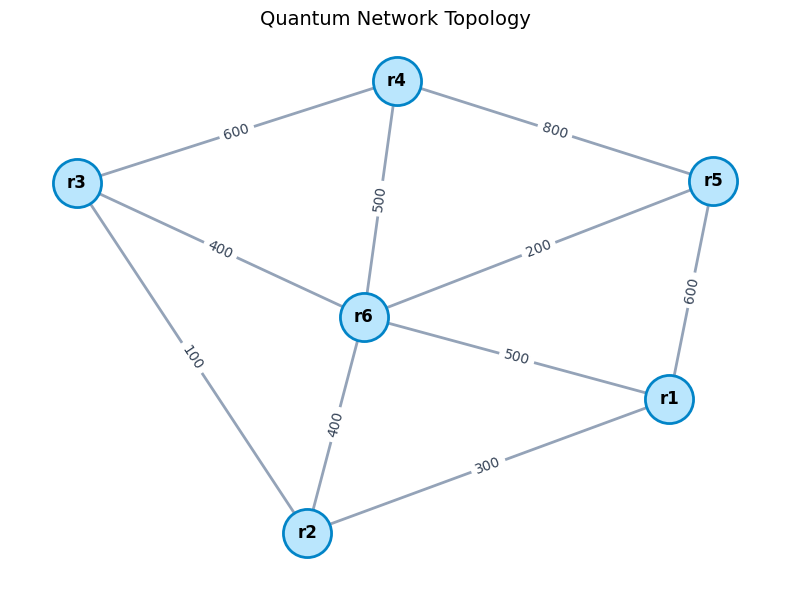

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

edges = [
    ("r1", "r2", 300), ("r1", "r6", 500), ("r1", "r5", 600),
    ("r2", "r3", 100), ("r2", "r6", 400), ("r3", "r6", 400),
    ("r3", "r4", 600), ("r4", "r6", 500), ("r4", "r5", 800),
    ("r5", "r6", 200)
]

# 1. Initialize the graph
G = nx.Graph()

# 2. Add the edges and their weights (distances)
for u, v, dist in edges:
    G.add_edge(u, v, weight=dist)

# 3. Set up the figure
plt.figure(figsize=(8, 6))

# 4. Create a layout for the nodes (spring_layout spaces them out nicely)
pos = nx.spring_layout(G, seed=42) 

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_color='#bae6fd', node_size=1200, edgecolors='#0284c7', linewidths=2)

# Draw the node labels (r1, r2, etc.)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw the edges
nx.draw_networkx_edges(G, pos, width=2, edge_color='#94a3b8')

# Draw the edge labels (the distances)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='#334155')

# 5. Render the plot
plt.title("Quantum Network Topology", fontsize=14)
plt.axis('off') # Hide the background axes
plt.tight_layout()
plt.show()

Network Manager: Computed direct-path fidelities and built weighted graph.
[Scheduled] Request r1 <-> r4 for T=1 (Memories: 3)
[Scheduled] Request r2 <-> r5 for T=1 (Memories: 2)
[Scheduled] Request r3 <-> r6 for T=1 (Memories: 1)
[Scheduled] Request r1 <-> r6 for T=1 (Memories: 5)
[Scheduled] Request r2 <-> r4 for T=4 (Memories: 2)

Starting Simulation from T=0 to T=5
Max Concurrent Requests/Tick: 3

[Clock: T=1] Processing... (4 in queue)
  -> [Executing] r1 <-> r4 | Memories: 3
  [Quantum] Sifting flow state for 0 -> 3...
  [Classical] Validated e* = (3, 5) (Spike: 0.075 -> 0.103)
  [Split] Dividing at 5-3. Sub-problems: (0->5) and (3->3)
  [Quantum] Sifting flow state for 0 -> 5...
  [Classical] Validated e* = (0, 5) (Spike: 0.043 -> 0.077)
  [Split] Dividing at 0-5. Sub-problems: (0->0) and (5->5)
     [Routing] Path Selected: [('r1', 'r6', 500), ('r6', 'r4', 500)] (Setup Delay: 1.0 ticks)
Swap attempt r1 <-> r4: 3/3 succeeded.
Final Fidelity of successful links: 0.8672
  -> [Exec

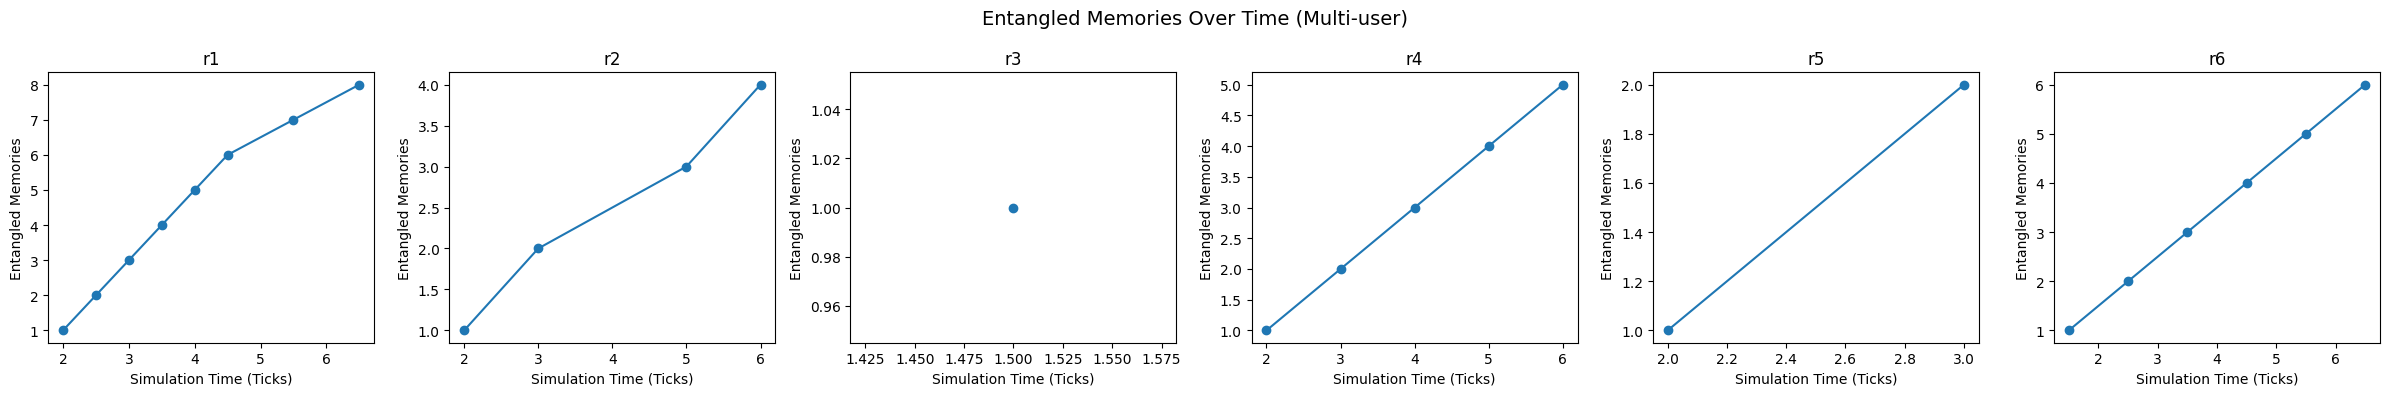

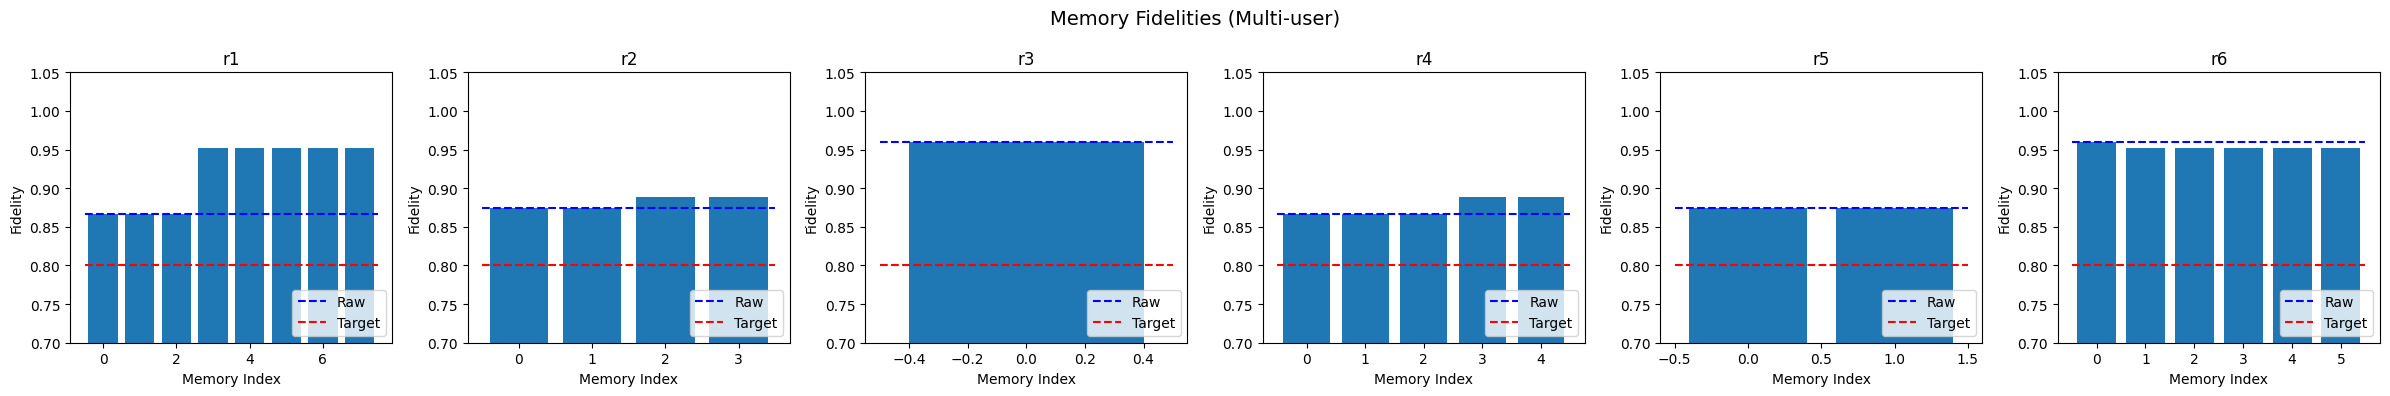

In [7]:
if __name__ == "__main__":
    # 1. Define Nodes and Edges
    nodes_list = [Node(10, f"r{i}") for i in range(1, 7)]
    edges = [
        ("r1", "r2", 300), ("r1", "r6", 500), ("r1", "r5", 600),
        ("r2", "r3", 100), ("r2", "r6", 400), ("r3", "r6", 400),
        ("r3", "r4", 600), ("r4", "r6", 500), ("r4", "r5", 800),
        ("r5", "r6", 200)
    ]

    # 2. Boot up the Network Manager with User-Defined Bounds & Delays
    network_manager = NetworkManager(
        nodes_list, 
        edges, 
        sim_start_time=0, 
        sim_end_time=5, 
        max_concurrent_requests=3,
        cc_delay=0.5,          # Classical delay per hop
        emission_delay=1     # Delay per photon emission
    )

    # 3. Schedule incoming network requests across different times
    network_manager.schedule_request(arrival_time=1, src_name="r1", dst_name="r4", no_memory=3)
    network_manager.schedule_request(arrival_time=1, src_name="r2", dst_name="r5", no_memory=2)
    network_manager.schedule_request(arrival_time=1, src_name="r3", dst_name="r6", no_memory=1)
    
    # The 4th request at T=1 will exceed the concurrency limit and spill over into T=2
    network_manager.schedule_request(arrival_time=1, src_name="r1", dst_name="r6", no_memory=5) 
    network_manager.schedule_request(arrival_time=4, src_name="r2", dst_name="r4", no_memory=2)
    
    # 4. Run the discrete-time simulation clock
    network_manager.run_simulation()
    
    # 5. Display the timeline graphs
    network_manager.plot_results()

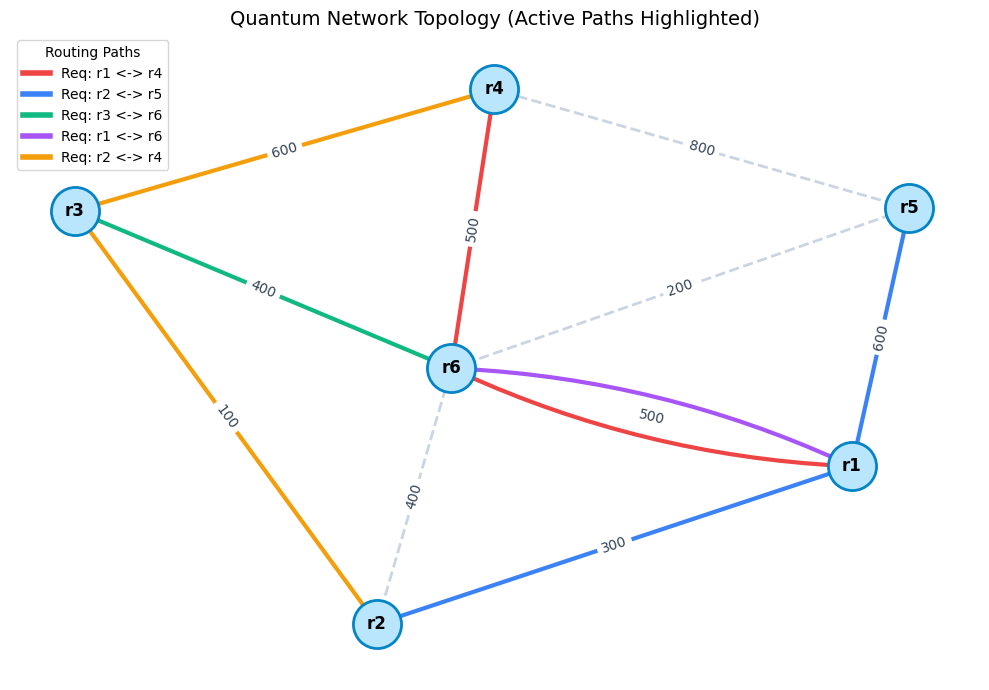

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict

# 1. Base Network Topology
edges = [
    ("r1", "r2", 300), ("r1", "r6", 500), ("r1", "r5", 600),
    ("r2", "r3", 100), ("r2", "r6", 400), ("r3", "r6", 400),
    ("r3", "r4", 600), ("r4", "r6", 500), ("r4", "r5", 800),
    ("r5", "r6", 200)
]

# 2. Paths extracted from your NEW simulation trace
used_paths = [
    [("r1", "r6"), ("r6", "r4")],            # Request 1: r1 <-> r4
    [("r2", "r1"), ("r1", "r5")],            # Request 2: r2 <-> r5
    [("r3", "r6")],                          # Request 3: r3 <-> r6
    [("r1", "r6")],                          # Request 4: r1 <-> r6
    [("r2", "r3"), ("r3", "r4")]             # Request 5: r2 <-> r4
]

request_labels = [
    "Req: r1 <-> r4", 
    "Req: r2 <-> r5", 
    "Req: r3 <-> r6", 
    "Req: r1 <-> r6", 
    "Req: r2 <-> r4"
]

# Distinct colors for each request (Red, Blue, Green, Purple, Orange)
colors = ['#ef4444', '#3b82f6', '#10b981', '#a855f7', '#f59e0b']

# 3. Map normalized edges to ALL their used colors
edge_usages = defaultdict(list)
legend_elements = []

for idx, path in enumerate(used_paths):
    color = colors[idx % len(colors)]
    label = request_labels[idx]
    
    # Add a custom line for the legend
    legend_elements.append(Line2D([0], [0], color=color, lw=4, label=label))
    
    for u, v in path:
        # Sort the tuple alphabetically to ensure bidirectional matching
        norm_edge = tuple(sorted((u, v)))
        edge_usages[norm_edge].append(color)

# 4. Initialize the graph
G = nx.Graph()
for u, v, dist in edges:
    G.add_edge(u, v, weight=dist)

# Separate the graph's edges into unused edges
normal_edges = []
for u, v in G.edges():
    norm_edge = tuple(sorted((u, v)))
    if norm_edge not in edge_usages:
        normal_edges.append((u, v))

# 5. Set up the plot
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42) # Keep the seed the same for consistent layout

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_color='#bae6fd', node_size=1200, edgecolors='#0284c7', linewidths=2)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# Draw the unused edges (faint, dashed)
nx.draw_networkx_edges(G, pos, edgelist=normal_edges, width=2, edge_color='#cbd5e1', style='dashed')

# Draw the USED edges with offsets (curves) for multiple usages
for (u, v), color_list in edge_usages.items():
    n_usages = len(color_list)
    
    # Calculate distinct curvatures (rads) for overlapping edges.
    # If n=1, rad=0 (straight line). If n>1, spreads them outward symmetrically.
    curvature_scale = 0.2
    rads = [curvature_scale * (i - (n_usages - 1) / 2) for i in range(n_usages)]
    
    for i, color in enumerate(color_list):
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=[(u, v)], 
            width=3, 
            edge_color=color, 
            connectionstyle=f'arc3, rad={rads[i]}', # Bends the overlapping lines
            arrows=True,       # Forces FancyArrowPatch to allow curves
            arrowstyle='-'     # Removes the arrowhead so it looks like an undirected link
        )

# Draw the edge distance labels
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, font_color='#334155')

# Add the custom legend
plt.legend(handles=legend_elements, loc='upper left', title="Routing Paths", fontsize=10)

# 6. Render
plt.title("Quantum Network Topology (Active Paths Highlighted)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()